In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load file CSV
df = pd.read_csv(r"D:\Ricky\CV & Achievements\CV Data Analyst\Portofolio Data Analyst\SQL\Retail-Sales-Analysis-SQL-Project--P1-main\Retail-Sales-Analysis-SQL-Project--P1-main\SQL - Retail Sales Analysis_utf .csv")
df

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantity,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,8:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,8:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0
...,...,...,...,...,...,...,...,...,...,...,...
1995,1857,2022-11-09,12:15:00,109,Male,60.0,Electronics,2.0,25.0,7.5,50.0
1996,211,2022-09-12,14:02:00,54,Male,42.0,Beauty,3.0,500.0,235.0,1500.0
1997,650,2023-10-08,12:41:00,98,Male,55.0,Electronics,1.0,30.0,15.0,30.0
1998,1211,2023-11-22,14:59:00,82,Male,42.0,Beauty,3.0,500.0,235.0,1500.0


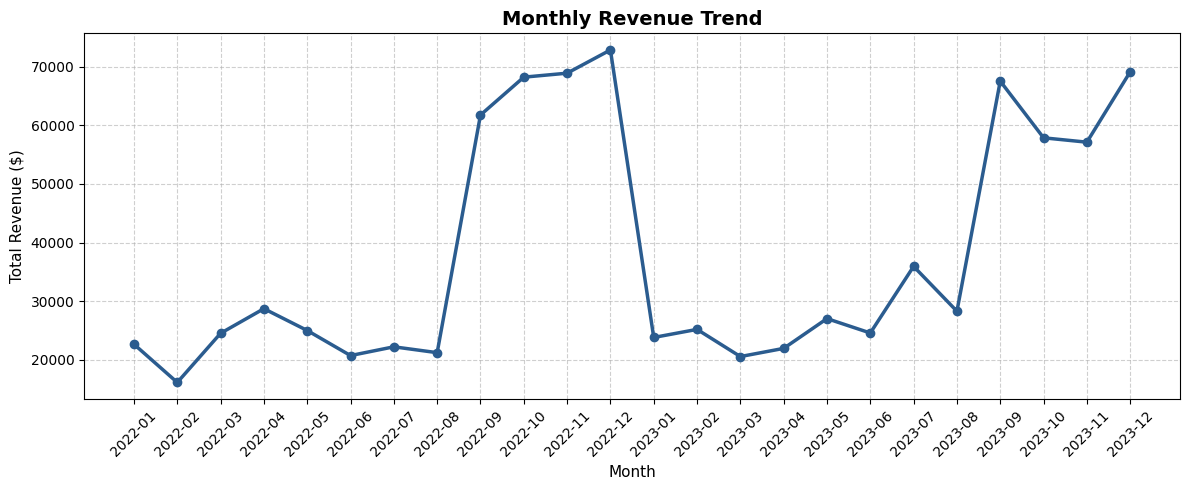

In [3]:
# Convert sale_date to datetime and aggregate monthly revenue
df['sale_date'] = pd.to_datetime(df['sale_date'])
monthly_sales = df.groupby(df['sale_date'].dt.to_period('M'))['total_sale'].sum().reset_index()
monthly_sales['sale_date'] = monthly_sales['sale_date'].astype(str)

# Plotting the Line Chart
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['sale_date'], monthly_sales['total_sale'], marker='o', color='#2b5c8f', linewidth=2.5)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

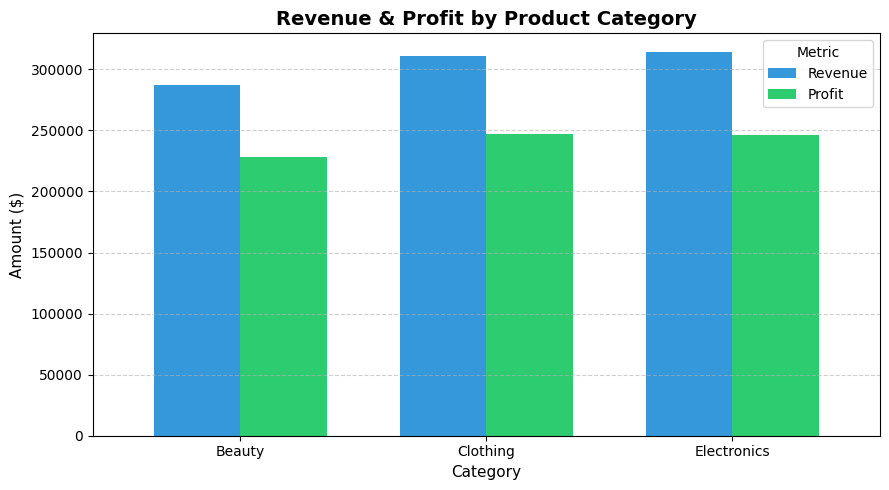

In [4]:
# Aggregate Gross Revenue and Net Profit (Total Sale - COGS)
cat_perf = df.groupby('category').agg(
    Revenue=('total_sale', 'sum'),
    Profit=('total_sale', lambda x: (x - df.loc[x.index, 'cogs']).sum())
)

# Plotting the Bar Chart
ax = cat_perf.plot(kind='bar', figsize=(9, 5), color=['#3498db', '#2ecc71'], width=0.7)
plt.title('Revenue & Profit by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=11)
plt.ylabel('Amount ($)', fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

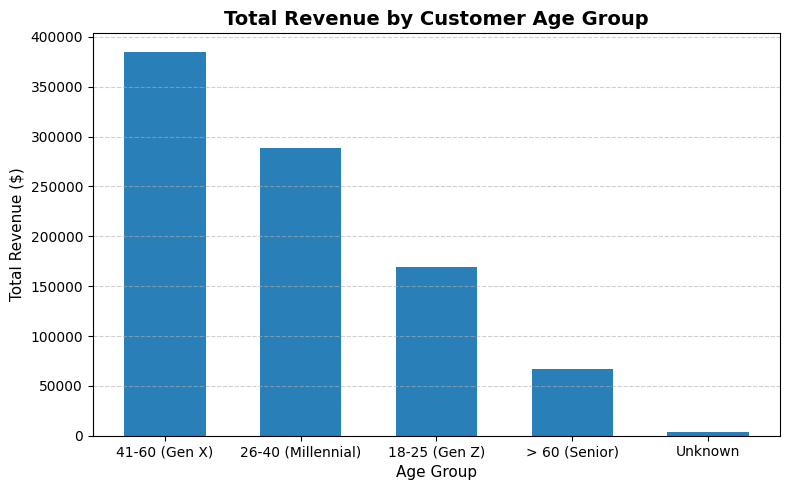

In [5]:
# Create Age Group Bins
def assign_age_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif 18 <= age <= 25:
        return '18-25 (Gen Z)'
    elif 26 <= age <= 40:
        return '26-40 (Millennial)'
    elif 41 <= age <= 60:
        return '41-60 (Gen X)'
    else:
        return '> 60 (Senior)'

df['age_group'] = df['age'].apply(assign_age_group)
age_sales = df.groupby('age_group')['total_sale'].sum().reset_index().sort_values(by='total_sale', ascending=False)

# Plotting the Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(age_sales['age_group'], age_sales['total_sale'], color='#2980b9', width=0.6)
plt.title('Total Revenue by Customer Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

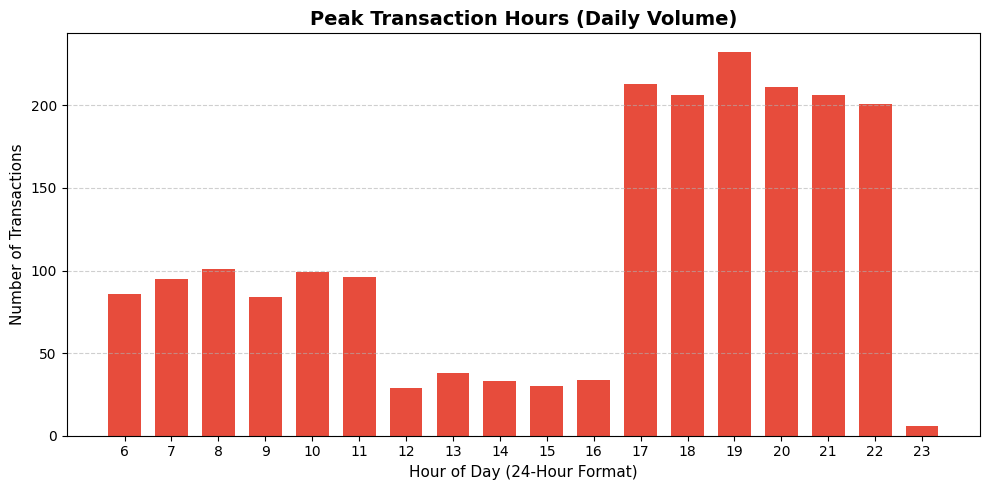

In [6]:
# Extract Hour from Transaction Time
df['hour'] = pd.to_datetime(df['sale_time'], format='%H:%M:%S').dt.hour
hourly_tx = df.groupby('hour')['transactions_id'].count().reset_index()

# Plotting Hourly Transactions
plt.figure(figsize=(10, 5))
plt.bar(hourly_tx['hour'], hourly_tx['transactions_id'], color='#e74c3c', width=0.7)
plt.title('Peak Transaction Hours (Daily Volume)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24-Hour Format)', fontsize=11)
plt.ylabel('Number of Transactions', fontsize=11)
plt.xticks(range(6, 24))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save image file to repository folder for GitHub README inclusion
plt.savefig('peak_hours_chart.png', dpi=300)
plt.show()